In [19]:
import pandas as pd
df_history = pd.read_csv('/kaggle/input/datasets/vijay4532/data-analytics-assignment/historical_data.csv')
df_sentiment = pd.read_csv('/kaggle/input/datasets/vijay4532/data-analytics-assignment/fear_greed_index.csv')

In [20]:
df_history['Timestamp IST'] = pd.to_datetime(df_history['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
df_history['date'] = df_history['Timestamp IST'].dt.date

df_sentiment['date'] = pd.to_datetime(df_sentiment['date']).dt.date
merged_df = pd.merge(df_history, df_sentiment, on='date', how='inner')
print(f"Total Merged Rows: {merged_df.shape[0]}")
print(merged_df.head(2))

Total Merged Rows: 211218
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
1         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   

   Crossed       Fee      Trade ID     Timestamp        date   timestamp  \
0     True  0.345404  8.950000e+14  1.730000e+12  2024-12-02  1733117400   
1     True  0.005600  4.430000e+14  1.730000e+12  2024-12-02  1733117400   

   value classification  
0     80  Extreme Gr

In [21]:
real_trades = merged_df[merged_df['Closed PnL'] != 0].copy()

result = real_trades.groupby('classification').agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean',
    'date': 'count'
}).rename(columns={'date': 'Total Trades'})
win_rate = real_trades.groupby('classification')['Closed PnL'].apply(lambda x: (x > 0).mean() * 100)
final_report = result.merge(win_rate.rename("Win Rate %"), on='classification')

print(final_report)

                Closed PnL     Size USD  Total Trades  Win Rate %
classification                                                   
Extreme Fear     71.027316  5467.570419         10406   76.215645
Extreme Greed   130.205309  2779.563632         20853   89.167026
Fear            112.625988  8041.140445         29808   87.288647
Greed            85.403927  5438.671764         25176   76.890690
Neutral          71.199993  5556.444833         18159   82.388898


/tmp/ipykernel_55/1319436592.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='classification', y='Closed PnL', palette='viridis')


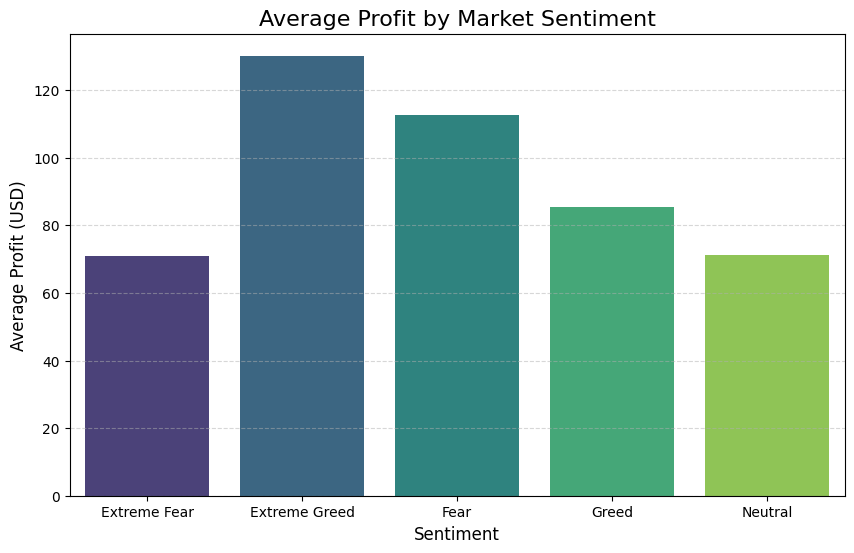

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
plot_data = final_report.reset_index()
sns.barplot(data=plot_data, x='classification', y='Closed PnL', palette='viridis')

plt.title('Average Profit by Market Sentiment', fontsize=16)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Average Profit (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()